In [1]:
! git checkout module-08

Already on 'module-08'


In [2]:
# Imports
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from zipfile import ZipFile
from urllib.request import urlretrieve

%matplotlib inline

In [3]:
def download_and_unzip(url, save_path):
    print(f"Downloading and extracting assests....", end="")

    # Downloading zip file using urllib package.
    urlretrieve(url, save_path)

    try:
        # Extracting zip file using the zipfile package.
        with ZipFile(save_path) as z:
            # Extract ZIP file contents in the same directory.
            z.extractall(os.path.split(save_path)[0])

        print("Done")

    except Exception as e:
        print("\nInvalid file.", e)

In [4]:
URL = r"https://www.dropbox.com/s/zuwnn6rqe0f4zgh/opencv_bootcamp_assets_NB8.zip?dl=1"

asset_zip_path = os.path.join(os.getcwd(), f"opencv_bootcamp_assets_NB8.zip")

# Download if assest ZIP does not exists. 
if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path) 

# Read Template and Scanned image

In [5]:
form = cv2.imread("form.jpg", cv2.IMREAD_COLOR)
form = cv2.cvtColor(form, cv2.COLOR_BGR2RGB)
scanned_form = cv2.imread("scanned-form.jpg", cv2.IMREAD_COLOR)
scanned_form = cv2.cvtColor(scanned_form, cv2.COLOR_BGR2RGB)

Text(0.5, 1.0, 'Scanned - Form')

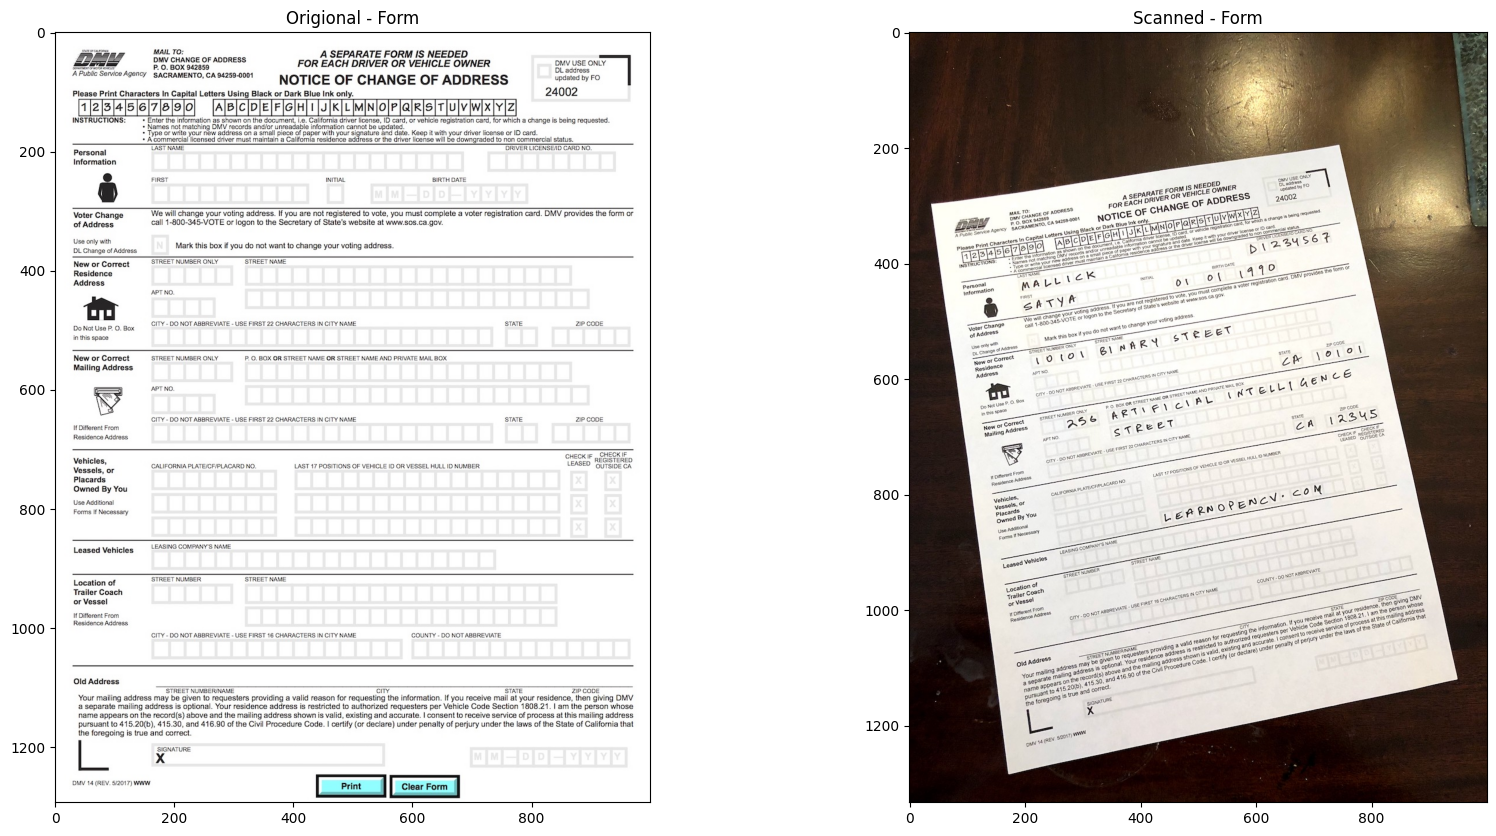

In [6]:
# display images
plt.figure(figsize = [20,10])

plt.subplot(121)
plt.imshow(form); plt.title("Origional - Form")
plt.subplot(122);plt.imshow(scanned_form); plt.title("Scanned - Form")

Text(0.5, 1.0, 'Scanned form')

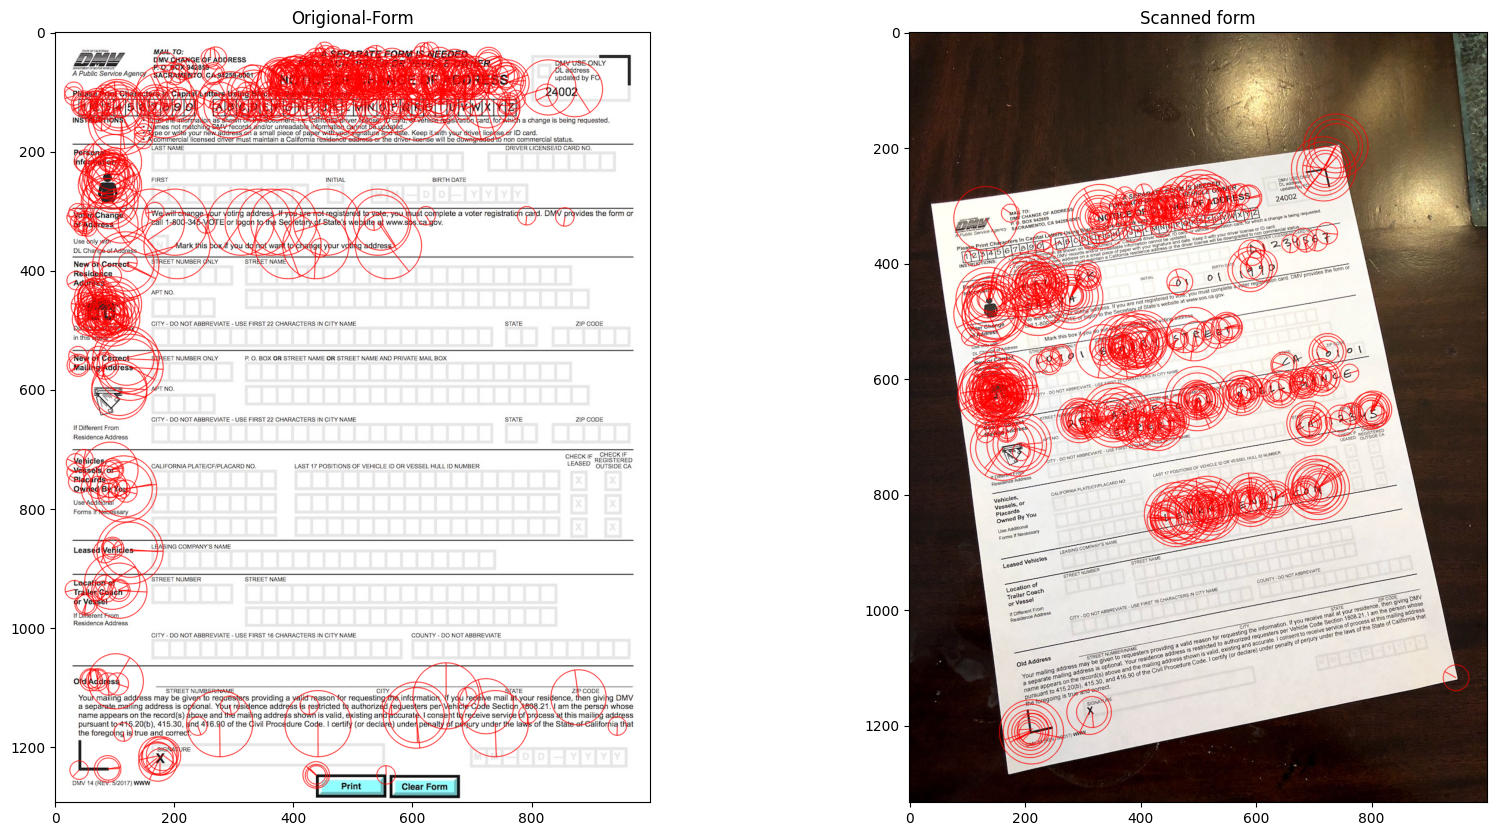

In [7]:
# converting to gray scale
form_gray = cv2.cvtColor(form, cv2.COLOR_RGB2GRAY)
scanned_form_gray = cv2.cvtColor(scanned_form, cv2.COLOR_RGB2GRAY)

# detect orb features and compute keypoints and decriptors
MAX_NUM_FEATURES = 500
orb = cv2.ORB_create(MAX_NUM_FEATURES)
keypoints1, descriptors1 = orb.detectAndCompute(form_gray, None)
keypoints2, descriptors2 = orb.detectAndCompute(scanned_form_gray, None)

# drawing and displaying
form_display = cv2.drawKeypoints(form, keypoints1, outImage = np.array([]), color = (255,0,0), flags = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
scanned_form_display = cv2.drawKeypoints(scanned_form, keypoints2, outImage = np.array([]), color = (255,0,0), flags = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.figure(figsize = [20,10])
plt.subplot(121); plt.imshow(form_display); plt.title("Origional-Form")
plt.subplot(122); plt.imshow(scanned_form_display); plt.title("Scanned form")

# Match keypoints in the two images

In [8]:
matcher = cv2.DescriptorMatcher_create(cv2.DESCRIPTOR_MATCHER_BRUTEFORCE_HAMMING)
matches = list(matcher.match(descriptors1,descriptors2, None))

matches.sort(key = lambda x: x.distance, reverse = None)
num_good_matches = int(len(matches)*0.10)
matches = matches[:num_good_matches]

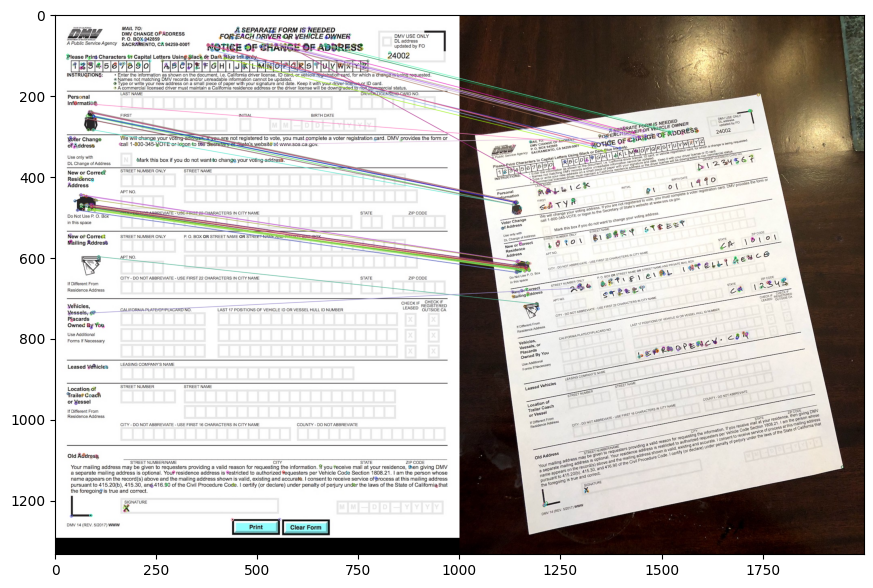

In [9]:
# draw the matches
img_matches = cv2.drawMatches(form, keypoints1, scanned_form, keypoints2, matches, None)
plt.figure(figsize = [20,7])
plt.imshow(img_matches)

# finding Homography

In [10]:
# extract location of good matches
points1 = np.zeros((len(matches), 2), dtype = np.float32)
points2 = np.zeros((len(matches), 2), dtype = np.float32)

for i, match in enumerate(matches):
    points1[i,:] = keypoints1[match.queryIdx].pt
    points2[i, :] = keypoints2[match.trainIdx].pt

# find homography 
homography , mask = cv2.findHomography(points2 ,points1,cv2.RANSAC)


In [11]:
print(homography)

[[ 1.39505012e+00 -2.03982809e-01 -6.33954227e+00]
 [ 2.19513291e-01  1.51700809e+00 -4.79626530e+02]
 [-6.80384513e-05  1.28362014e-04  1.00000000e+00]]


# wrap the image 

Text(0.5, 1.0, 'Scanned Image after warping')

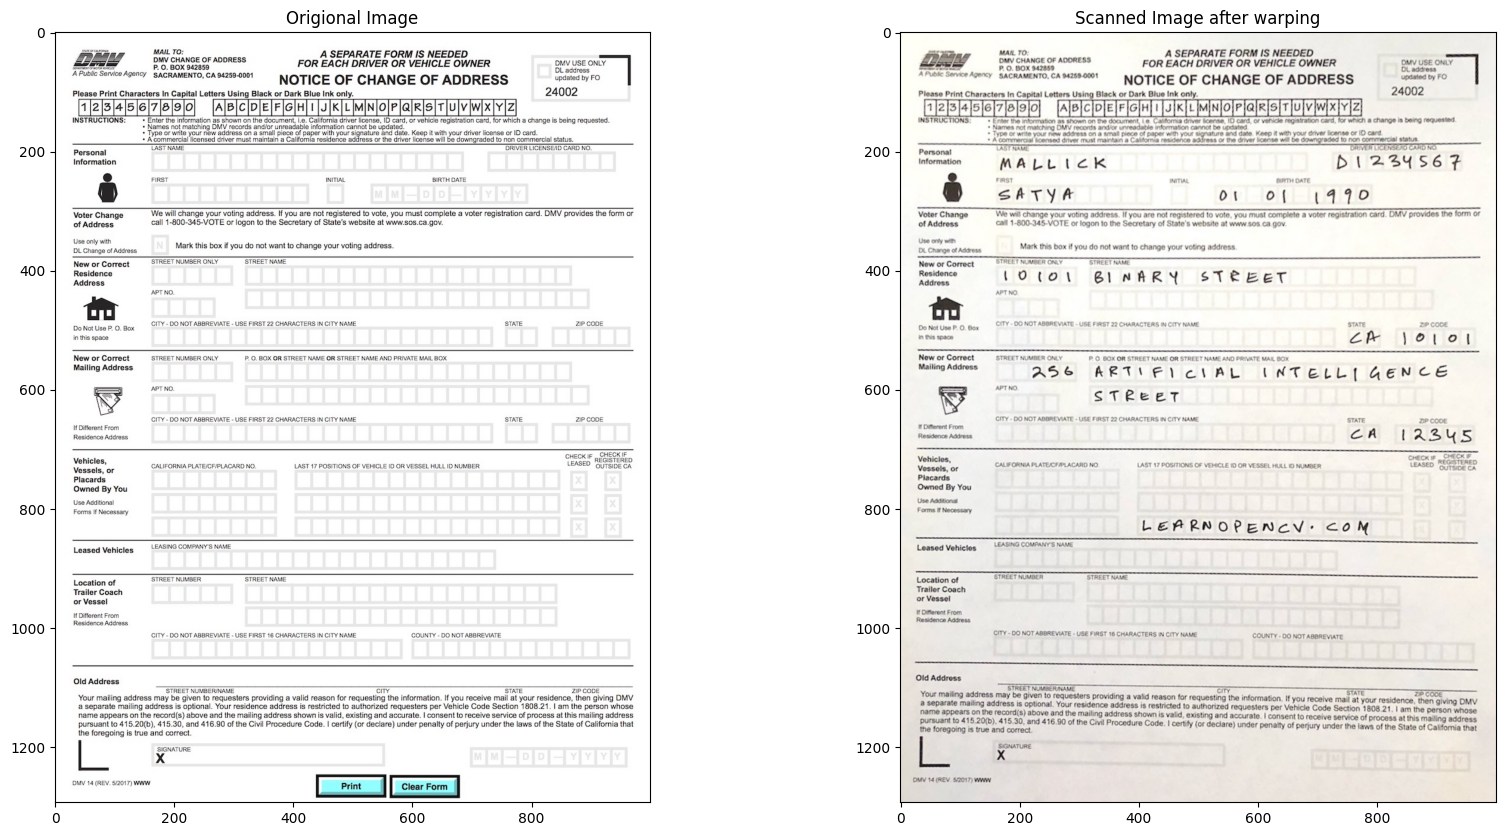

In [12]:
height , width , channels = form.shape
scanned_form_warped = cv2.warpPerspective(scanned_form, homography, (width, height))

# displaying both images
plt.figure(figsize = [20,10])
plt.subplot(121); plt.imshow(form); plt.title("Origional Image")
plt.subplot(122); plt.imshow(scanned_form_warped); plt.title("Scanned Image after warping")

In [13]:
! git status


On branch module-08
Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.ipynb_checkpoints/
	car_reflection.jpg
	form.jpg
	module-08.ipynb
	opencv_bootcamp_assets_NB1.zip
	opencv_bootcamp_assets_NB2.zip
	opencv_bootcamp_assets_NB3.zip
	opencv_bootcamp_assets_NB4.zip
	opencv_bootcamp_assets_NB6.zip
	opencv_bootcamp_assets_NB8.zip
	race_car.mp4
	race_car_out.avi
	race_car_out.mp4
	scanned-form.jpg

nothing added to commit but untracked files present (use "git add" to track)


In [ ]:
! git add module-08.ipynb 